## Required packages before use in this order

> *pip install git+https://github.com/amr8004/ESPEI.git* <br>
<br>
> *pip install git+https://github.com/amr8004/pycalphad.git*

In [1]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pydantic\_migration.py:283: UserWarning: `pydantic:PyObject` has been moved to `pydantic.types:ImportString`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
os.chdir('C:/Users/xander/Documents/github_repositories/PureElement')
os.getcwd()

'C:\\Users\\xander\\Documents\\github_repositories\\PureElement'

In [3]:

element = 'Nb'
#csvName = r'C:/Users/xander/Documents/github_repositories/PureElement/CpCSV/{element}_CP_data.csv'
csvName = f'CpCSV/{element}_CP_data.csv'
jsonName = f'CpJson/{element}_CP.json'

# Read the CSV and add the data to a dictionary
df=pd.read_csv(csvName, header=[0,0])
header = df.columns.tolist()
data = {}
for col in header:
    column_values = df[col].values.flatten().tolist()
    data[col[0]] = column_values[::]

In [4]:
print(data.keys())
data['Temperature: K']

dict_keys(['Temperature: K', 'Heat capacity at constant pressure Cp: J/K/mol', 'Uncertainty', 'Pressure', 'Ref Temp', 'Data Set ID', 'State', 'Representation', 'Method', 'Description', 'Purity', 'Purity Units', 'Year'])


[2.563,
 3.11,
 4.282,
 4.675,
 5.228,
 7.42,
 3.233,
 3.996,
 6.144,
 8.63,
 10.475,
 2.55,
 2.673,
 2.964,
 3.106,
 3.137,
 3.257,
 3.412,
 3.465,
 3.539,
 3.597,
 3.65,
 3.697,
 3.752,
 3.794,
 3.795,
 3.835,
 3.882,
 3.947,
 3.979,
 4.042,
 4.101,
 4.137,
 4.163,
 4.215,
 4.277,
 4.286,
 4.353,
 4.417,
 4.417,
 4.449,
 4.499,
 4.577,
 4.668,
 4.7,
 4.769,
 4.788,
 4.795,
 4.809,
 4.81,
 4.866,
 4.952,
 5.04,
 5.041,
 5.045,
 5.082,
 5.116,
 5.121,
 5.201,
 5.221,
 5.224,
 5.299,
 5.394,
 5.435,
 5.466,
 5.505,
 5.534,
 5.582,
 5.622,
 5.625,
 5.753,
 5.772,
 5.837,
 5.87,
 6.42,
 6.45,
 6.576,
 6.601,
 6.846,
 7.399,
 7.416,
 7.822,
 7.835,
 7.839,
 8.055,
 8.16,
 8.313,
 8.344,
 8.344,
 8.499,
 8.802,
 8.822,
 8.966,
 9.025,
 9.137,
 9.374,
 9.474,
 9.801,
 9.992,
 10.162,
 10.477,
 10.502,
 10.545,
 10.957,
 2.857,
 3.232,
 3.275,
 3.413,
 3.664,
 3.742,
 3.791,
 3.846,
 3.889,
 4.003,
 4.066,
 4.149,
 4.348,
 4.451,
 4.734,
 4.749,
 4.969,
 5.23,
 5.725,
 5.765,
 5.834,
 5.905,


In [5]:
if 'Temperature: K' in data:
    data['Temp'] = data.pop('Temperature: K')
else:
    print("Key ['Temperature: K'] does not exist in the data dictionary.")


In [6]:
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(jsonName), exist_ok=True)

# Open the file
with open(jsonName, 'w') as file:
    json.dump(data, file)

In [7]:
Define_Element([element.upper()])
data=imp_data_PE(jsonName)

In [8]:
# Load data from CSV
#data = pd.read_csv('sr_ipynb/Cr_Cp.txt', sep="\t")

# Extract columns
temp = data['Temp'].values
cp = data['Heat capacity at constant pressure Cp: J/K/mol'].values



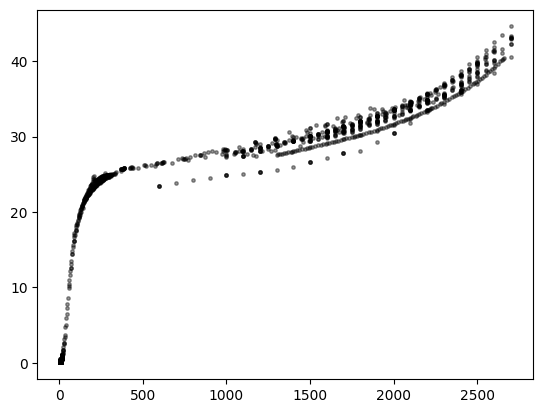

In [9]:
plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')

In [10]:
# Initial guess for parameters
initial_params = [230, 1e-3, 1e-6]  # You can adjust these initial guesses
initial_5params = [300, 1e-3, 0.01, 800, 300]
#initial_5params = [225, 1e-4, 1e-3, 150, 350]
nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [11]:
from espei.pureElement import log_probability

In [12]:
# Number of walkers and number of steps
nwalkers = 12
nsteps = 4000

model_flag='SRModelE'

# Set up the sampler
ndim = len(initial_5params)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_5params))
    for n,v in enumerate(initial_5params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
pos2 = [initial_5params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
# Run the MCMC sampling
sampler.run_mcmc(pos, nsteps, progress=True)


100%|██████████| 4000/4000 [08:23<00:00,  7.94it/s]


State([[2.05248230e+02 2.84995740e-03 6.66985827e-02 4.81151534e+03
  3.50186618e+03]
 [2.06674614e+02 2.90243320e-03 5.73777434e-02 4.53207691e+03
  3.23580909e+03]
 [2.07132087e+02 2.96596823e-03 8.62158123e-02 5.81456227e+03
  4.46727777e+03]
 [2.04783434e+02 3.02457087e-03 4.02900349e-02 3.41504182e+03
  2.03227834e+03]
 [2.06592149e+02 2.86943066e-03 5.31897810e-02 4.29639418e+03
  3.01841880e+03]
 [2.09941308e+02 2.82656712e-03 5.18129195e-02 4.17761490e+03
  2.91442163e+03]
 [2.09430180e+02 3.02192170e-03 7.49167128e-02 4.94052877e+03
  3.52906454e+03]
 [2.05453997e+02 3.00580373e-03 8.03370576e-02 5.25351706e+03
  3.85738169e+03]
 [2.08945906e+02 2.90621953e-03 2.80517109e-02 2.89394030e+03
  1.59794002e+03]
 [2.07954645e+02 3.01098862e-03 6.12661919e-02 4.49266799e+03
  3.11027053e+03]
 [2.05374755e+02 3.15069104e-03 6.95280504e-02 4.54411416e+03
  3.06563606e+03]
 [2.07510930e+02 2.87826145e-03 5.49491315e-02 4.33050328e+03
  3.04052966e+03]], log_prob=[-420.24669544 -418.200

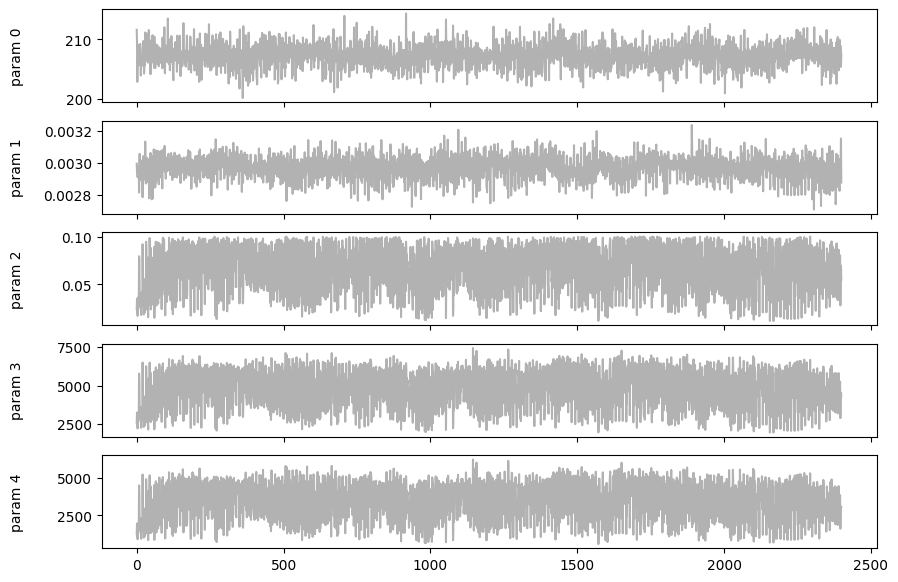

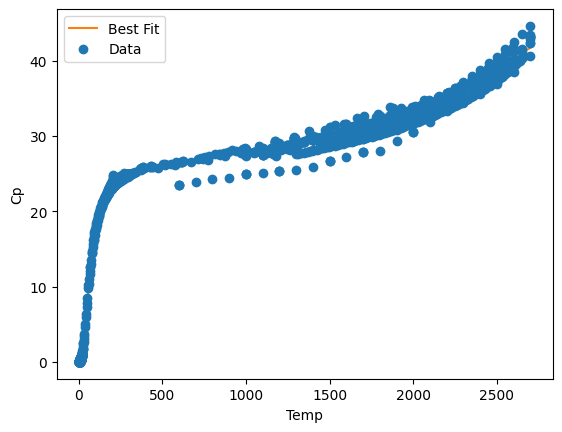

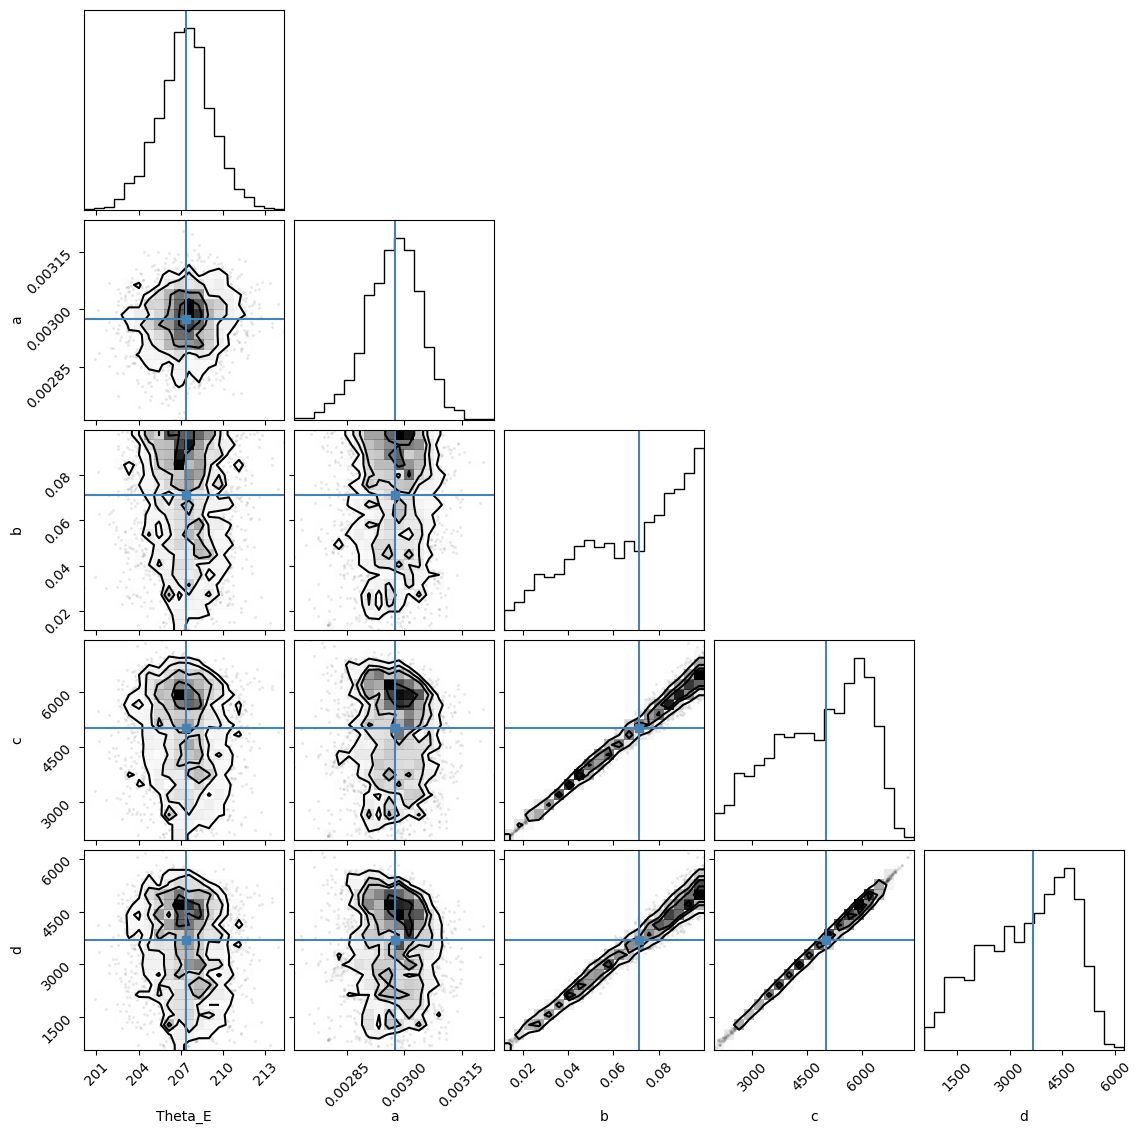

In [13]:
# Extract samples
samples = sampler.get_chain(flat=True, discard=1000, thin=15)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples, labels=["Theta_E", "a", "b","c","d"], truths=best_params)
plt.show()


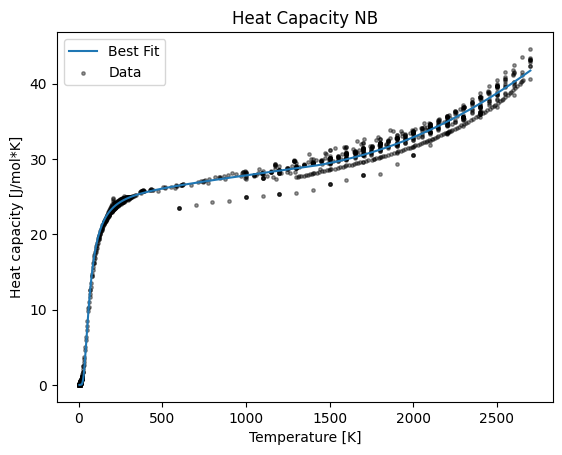

In [14]:
# Plot the best-fit curve with uncertainties
best_params = np.median(samples, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Best Fit')


plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

In [15]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([2.07344248e+02, 2.97451113e-03, 7.13919412e-02, 5.03316034e+03,
       3.67811614e+03])

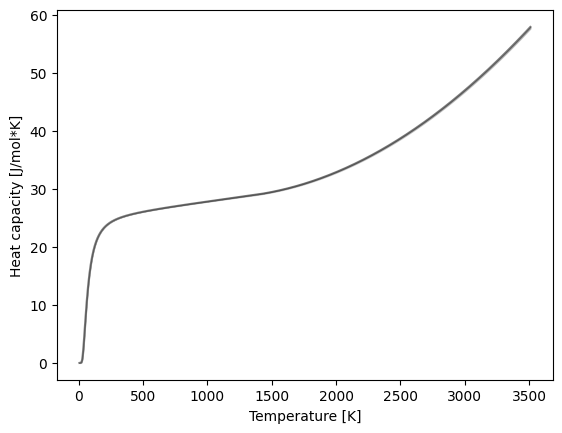

In [16]:
best_params = np.median(samples, axis=0)
mean_params = np.mean(samples, axis=0)
rangeSR=np.percentile(samples, [40, 50, 84], axis=0)
T_plot = np.linspace(min(temp), max(temp)*1.3, 1000)

plt.figure()
#plt.errorbar(temp, cp, fmt='o', label='Data', color = 'grey', alpha = 0.1)
#plt.plot(T_plot, SRModelE(T_plot, *best_params), label='Median', color = 'b')
#plt.plot(T_plot, SRModelE(T_plot, *mean_params), label='Mean', color = 'red')
plt.plot(T_plot, SRModelE(T_plot, *rangeSR[1]), label='50th', color = 'k', alpha = 0.5)
sixteenth=SRModelE(T_plot, *rangeSR[0])
eightyfourth=SRModelE(T_plot, *rangeSR[2])
plt.fill_between(T_plot, sixteenth, eightyfourth, color='grey', alpha=0.5)
plt.plot
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
#plt.legend()
plt.show()

In [17]:
s1 = np.std(samples[:,0], ddof=1)
s2 = np.std(samples[:,1], ddof=1)
s3 = np.std(samples[:,2], ddof=1)
s4 = np.std(samples[:,3], ddof=1)
s5 = np.std(samples[:,4], ddof=1)

In [18]:
print('Standard deviation of Theta_E:', s1)
print('Standard deviation of a:', s2)
print('Standard deviation of b:', s3)
print('Standard deviation of c:', s4)
print('Standard deviation of d:', s5)

Standard deviation of Theta_E: 1.9217905764429672
Standard deviation of a: 7.023353925326451e-05
Standard deviation of b: 0.023662184762669018
Standard deviation of c: 1243.0418329441331
Standard deviation of d: 1247.2331866919383


In [19]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 1000

model_flag='CSModelE'

# Set up the sampler
ndim = len(initial_params)
sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler2.run_mcmc(pos, nsteps)


State([[2.05124771e+02 2.44162859e-03 1.95734944e-13]
 [2.09238783e+02 2.47111364e-03 1.94865873e-13]
 [2.03606704e+02 2.48504683e-03 1.91778356e-13]
 [2.06312123e+02 2.48432425e-03 1.93283659e-13]
 [2.05454645e+02 2.46200530e-03 1.90449604e-13]
 [2.05576949e+02 2.43479327e-03 1.93079790e-13]
 [2.05157940e+02 2.38071232e-03 2.02551946e-13]
 [2.09113069e+02 2.49765119e-03 1.90771347e-13]
 [2.02876674e+02 2.52898376e-03 1.89783457e-13]
 [2.03333889e+02 2.39906462e-03 2.01345498e-13]
 [2.03678505e+02 2.49217978e-03 1.91402882e-13]
 [2.01863931e+02 2.51131476e-03 1.92225478e-13]
 [2.08694232e+02 2.50076560e-03 1.89851315e-13]
 [2.03265391e+02 2.50612913e-03 1.89317820e-13]
 [2.02807780e+02 2.41884216e-03 1.95338144e-13]
 [2.04631850e+02 2.44217185e-03 1.93258163e-13]
 [2.04775805e+02 2.40057186e-03 1.97984460e-13]
 [2.03086795e+02 2.45219398e-03 1.94273640e-13]
 [2.02813151e+02 2.40128985e-03 1.98907660e-13]
 [2.02863773e+02 2.39159519e-03 2.00312063e-13]
 [2.02928555e+02 2.37014846e-03 2.

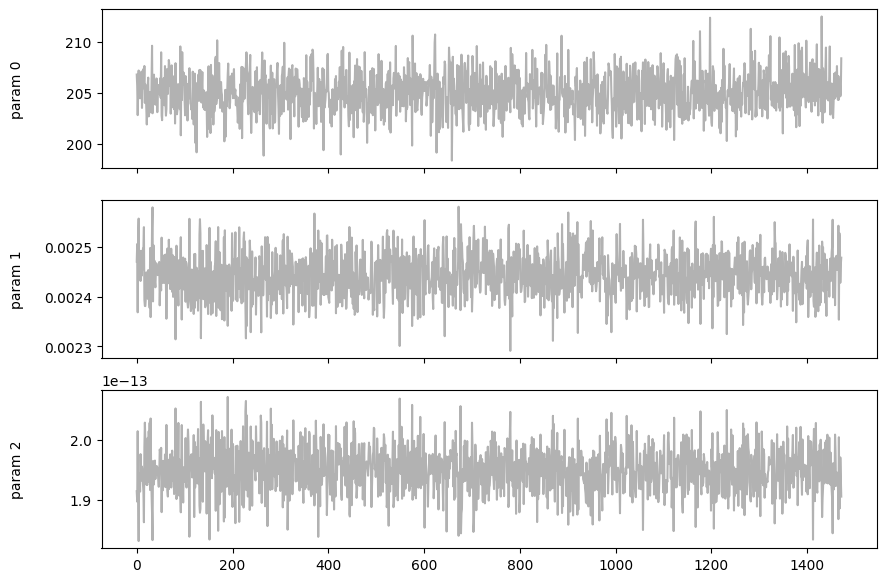

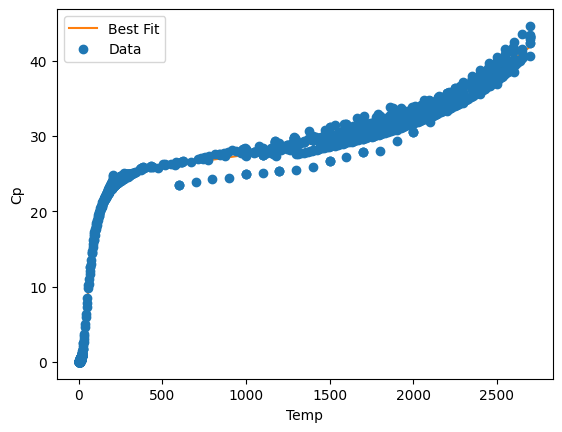

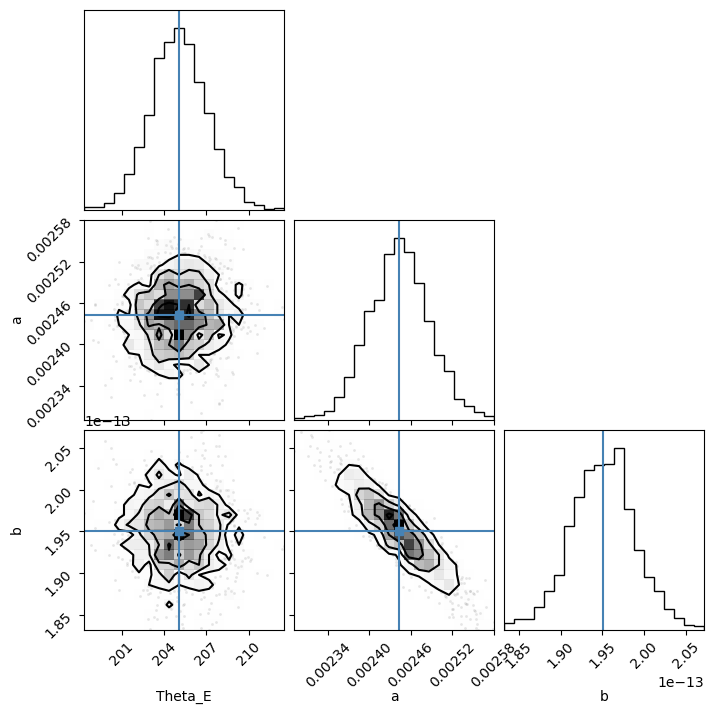

In [20]:
# Extract samples
samples2 = sampler2.get_chain(discard=300, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples2[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params2 = np.median(samples2, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples2, labels=["Theta_E", "a", "b"], truths=best_params2)
plt.show()


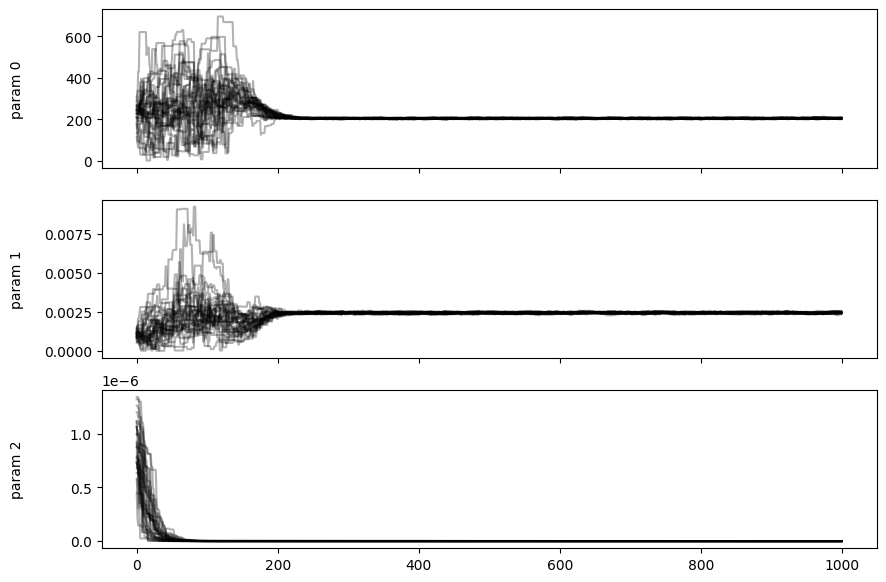

In [21]:
unflat2=sampler2.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [22]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.14f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
best_params2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

array([2.05063835e+02, 2.44269710e-03, 1.95050686e-13])

In [23]:
# Number of walkers and number of steps
nwalkers = 32
nsteps = 2000

model_flag='RWModelE'

# Set up the sampler
ndim = len(initial_params)
sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(temp, cp, model_flag))

# Initialize walkers
#pos = [initial_params + 1e-4*np.random.randn(ndim) for _ in range(nwalkers)]
pos = []
for i in range(nwalkers):
    re = []
    std = np.random.randn(len(initial_params))
    for n,v in enumerate(initial_params):
        va = v + 0.25*std[n]*v
        re.append(va)
    pos.append(np.array(re))
# Run the MCMC sampling
sampler3.run_mcmc(pos, nsteps)


State([[1.99173827e+02 1.31521489e-04 2.05373508e-06]
 [1.97872456e+02 2.59054208e-06 2.09478059e-06]
 [1.96335255e+02 1.16752089e-04 2.06115340e-06]
 [2.00490244e+02 3.30645027e-05 2.08524837e-06]
 [1.99134044e+02 1.63188363e-04 2.05085413e-06]
 [1.97263181e+02 1.18121019e-04 2.06177387e-06]
 [1.97549510e+02 3.29349597e-05 2.11363380e-06]
 [1.99017373e+02 6.20612544e-05 2.08134392e-06]
 [1.95581066e+02 6.62680962e-05 2.08613935e-06]
 [2.01887045e+02 3.13026980e-05 2.11381272e-06]
 [1.95990531e+02 5.41971467e-05 2.08473820e-06]
 [1.97612790e+02 1.84539524e-05 2.09987488e-06]
 [1.95132326e+02 3.53758246e-05 2.10987291e-06]
 [1.96161621e+02 1.83832112e-04 2.03667332e-06]
 [1.95989842e+02 1.88294694e-05 2.09653190e-06]
 [1.94667007e+02 3.28080596e-05 2.09271853e-06]
 [1.94744418e+02 6.43710118e-06 2.11012786e-06]
 [1.97287318e+02 1.39950402e-04 2.03647425e-06]
 [1.96238994e+02 5.31495567e-05 2.10503208e-06]
 [1.97295827e+02 3.61051003e-05 2.10114559e-06]
 [1.97778713e+02 7.31255417e-05 2.

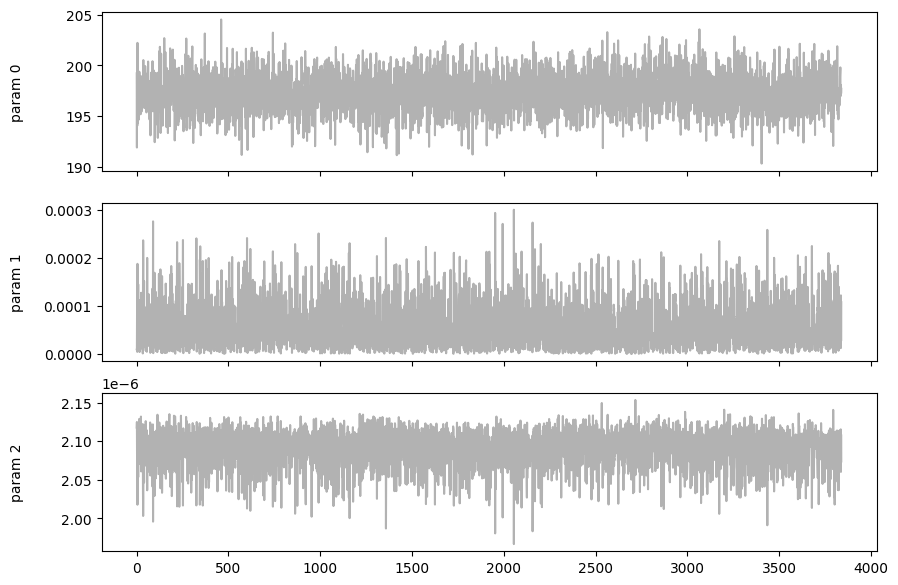

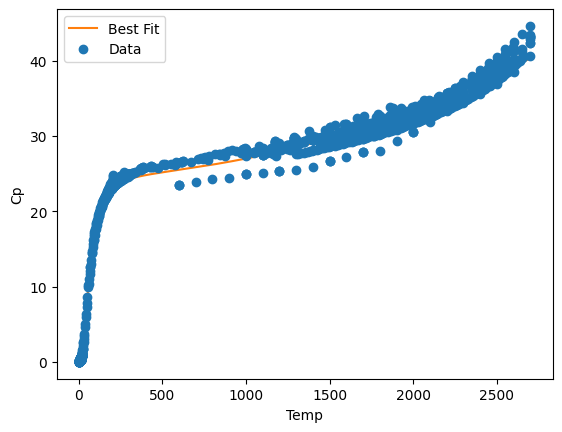

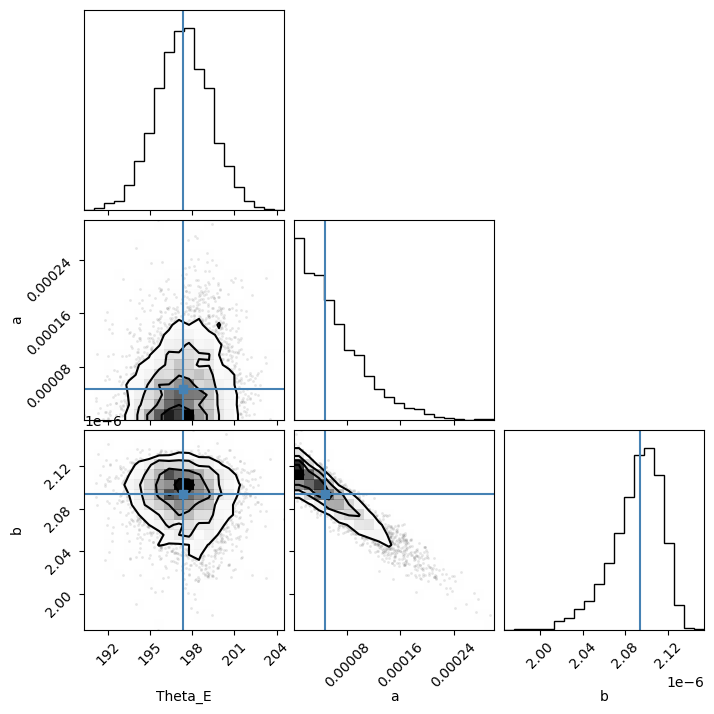

In [24]:
# Extract samples
samples3 = sampler3.get_chain(discard=200, thin=15, flat=True)

# Plot the chains
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples3[:, i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

# Plot the best-fit curve with uncertainties
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.errorbar(temp, cp, fmt='o', label='Data')
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='Best Fit')
plt.xlabel('Temp')
plt.ylabel('Cp')
plt.legend()
plt.show()

#Corner plot for visualizing parameter distributions
import corner
fig = corner.corner(samples3, labels=["Theta_E", "a", "b"], truths=best_params3)
plt.show()


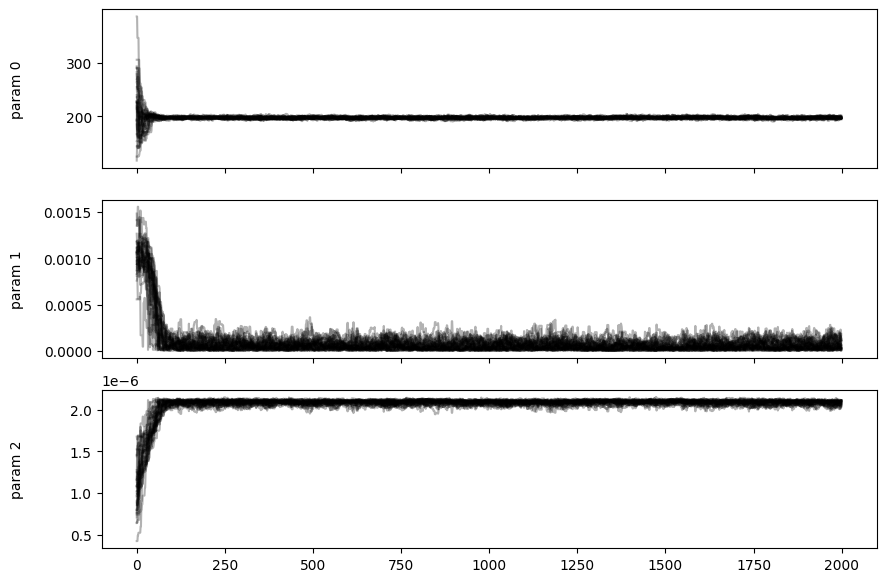

In [25]:
unflat2=sampler3.get_chain()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(unflat2[:,:,i], color="k", alpha=0.3)
    ax.set_ylabel(f"param {i}")
    ax.yaxis.set_label_coords(-0.1, 0.5)

In [26]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(samples3[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params3)
for i in range(ndim):
    mcmc = np.percentile(samples2[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params2)
for i in range(ndim):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.6f}_{{-{1:.10f}}}^{{{2:.10f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], f"param {i}")
    display(Math(txt))
print(best_params)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[1.97347506e+02 4.65519069e-05 2.09369432e-06]


<IPython.core.display.Math object>

...

[2.05063835e+02 2.44269710e-03 1.95050686e-13]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

[2.07344248e+02 2.97451113e-03 7.13919412e-02 5.03316034e+03
 3.67811614e+03]


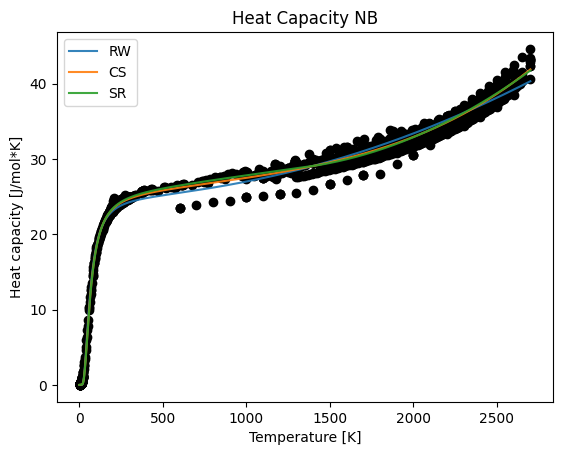

In [27]:
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(1, max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k')#,s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.gca().set_aspect(30)
#plt.xlim(0,200)
#plt.ylim(0,50)
plt.show()

In [28]:
RW=(RWModelE(T_plot, *best_params3))*(6.022e23)*(1.380649e-23)
CS=(CSModelE(T_plot, *best_params2))*(6.022e23)*(1.380649e-23)
SR=(np.array(SRModelE(T_plot, *best_params)))*(6.022e23)*(1.380649e-23)
cp2=(cp)*(6.022e23)*(1.380649e-23)

In [29]:
print(RW[0],CS[0],SR[0])

0.0004044525790876128 0.020309239023536027 0.024730883498785116


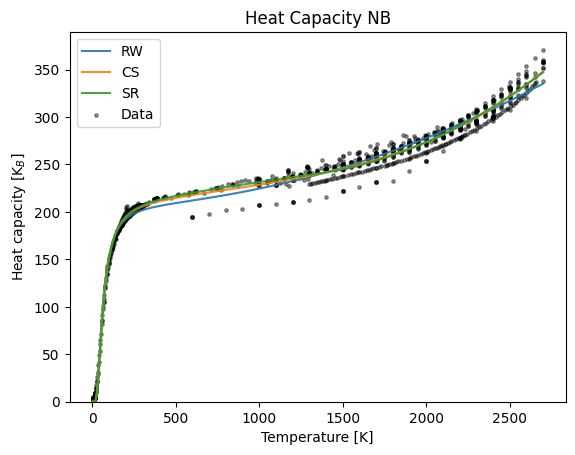

In [30]:
plt.figure()
plt.plot(T_plot, RW, label='RW', alpha=0.9)
plt.plot(T_plot, CS, label='CS', alpha=0.9)
plt.plot(T_plot, SR, label='SR', alpha=0.9)

plt.scatter(temp, cp2, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [K$_{B}$]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
#plt.xlim(300,900)
plt.ylim(0)
plt.show()

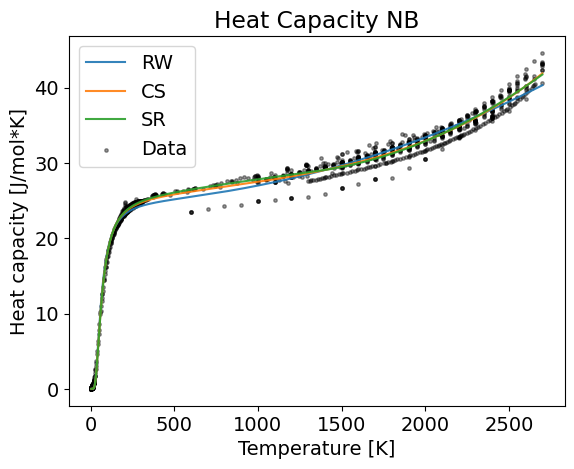

In [31]:
plt.rcParams.update({'font.size': 14})
best_params3 = np.median(samples3, axis=0)
T_plot = np.linspace(min(temp), max(temp), 1000)
plt.figure()
plt.plot(T_plot, RWModelE(T_plot, *best_params3), label='RW', alpha=0.9)
plt.plot(T_plot, CSModelE(T_plot, *best_params2), label='CS', alpha=0.9)
plt.plot(T_plot, SRModelE(T_plot, *best_params), label='SR', alpha=0.9)

plt.scatter(temp, cp, color='k',s=6, alpha=0.4, label='Data')
plt.xlabel("Temperature [K]")
plt.ylabel("Heat capacity [J/mol*K]")
plt.title(f"Heat Capacity {RTDB_globals['element'][0]}")
plt.legend()
plt.show()

c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\io\tdb.py:925: UserWarning: The type definition character `I` was defined in the following phases: ['CBCC_A12', 'BCC_A2', 'FCC_A1', 'HCP_A3'], but no corresponding TYPE_DEFINITION line was found in the TDB.
  warnings.warn(f"The type definition character `{typechar}` was defined in the following phases: "


-20.565849281099467 <class 'numpy.ndarray'> 200
4.759875405809745e-05 <class 'numpy.ndarray'> 200
sr


Text(0.5, 1.0, 'Gibbs NB')

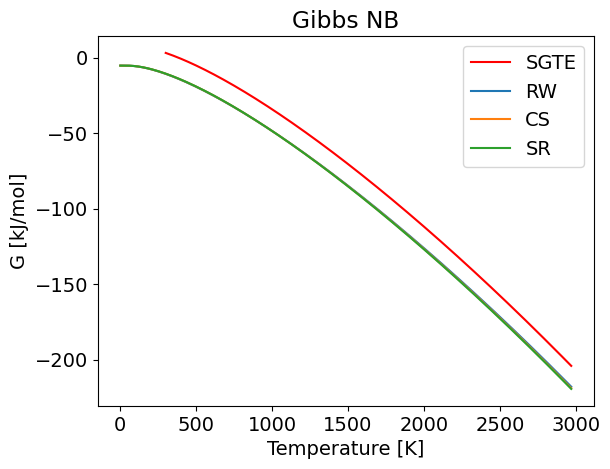

In [32]:
CSa=best_params2[1]
CSb=best_params2[2]
CSE=best_params2[0]

RWE = best_params3[0]
RWa=best_params3[1]
RWb=best_params3[2]

RTDB_globals['Te_final'] = best_params[0]
RTDB_globals['k1_final'] = best_params[1]
RTDB_globals['k2_final'] = best_params[2]
RTDB_globals['alfa_final'] = best_params[3]
RTDB_globals['g_final'] = best_params[4]
from pycalphad import Database, calculate, equilibrium, variables as v
db_sgte = Database('sgte-unary.tdb')
T_range = np.linspace(1,data.Temp.max()*1.1,num=200)
fcc_GM = calculate(db_sgte, [element.upper(), 'VA'], 'FCC_A1', P=101325, T=(300, max(T_range), 10), N=1)
plt.plot(fcc_GM.T, fcc_GM.GM.squeeze()/1000, label='SGTE', color = 'r')
GRW=pype.GTRWM(T_range,RWa,RWb)
GRW1=GRW+pype.GEin(RWE,T_range)
plt.plot(T_range,GRW1/1000,label='RW')
GCStest=pype.GTCSM(T_range,CSa,CSb)
GCS1=GCStest+pype.GEin(CSE,T_range)
plt.plot(T_range,GCS1/1000,label='CS')
GSR=autoG(T_range,'SRModelE')
GSRtest=pype.GEin(RTDB_globals['Te_final'],T_range)+pype.GTBCM(T_range,RTDB_globals['k1_final'],RTDB_globals['k2_final'],RTDB_globals['alfa_final'],RTDB_globals['g_final'])#+pype.GibbsM_Bosse(T_range)
plt.plot(T_range,GSRtest/1000, label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("G [kJ/mol]")
plt.legend()
plt.title(f"Gibbs {RTDB_globals['element'][0]}")

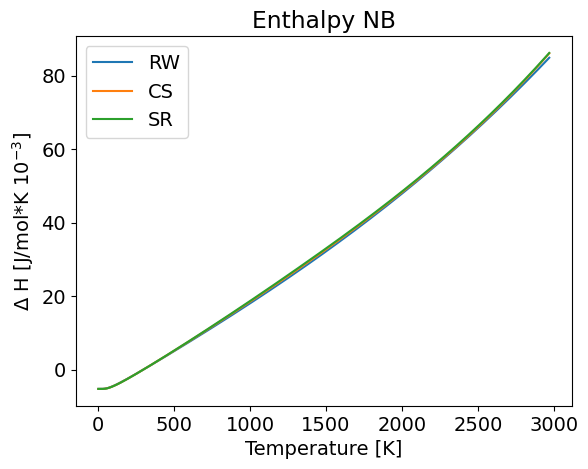

In [33]:
HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSE,298.15)#+pype.HM(T_range)[29]
HSR298=pype.HTBCM(298.15,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],298.15)#+pype.HM(T_range)[149]
HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)#+pype.HM(T_range)[149]
HCS=pype.HTCSM(T_range,CSa,CSb)+pype.HEin(CSE,T_range)#+pype.HM(T_range)
HCS2=HCS-HCS298
HSR2=pype.HTBCM(T_range,RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])+pype.HEin(RTDB_globals['Te_final'],T_range)#+pype.HM(T_range)
HSR=HSR2-HSR298
HRW2=pype.HTRWM(T_range,RWa,RWb)+pype.HEin(RWE,T_range)#+pype.HM(T_range)
HRW=HRW2-HRW298
plt.plot(T_range,10**-3*HRW,label='RW')
plt.plot(T_range,10**-3*HCS2,label='CS')
plt.plot(T_range,10**-3*HSR,label='SR')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
plt.title("H_Ein+H_BCM-H298.15")
plt.title(f"Enthalpy {RTDB_globals['element'][0]}")
plt.legend()

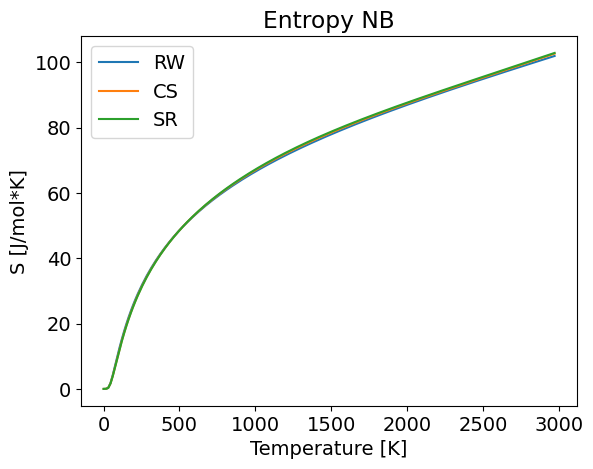

In [34]:
SE1=pype.SEin(RTDB_globals['Te_final'],T_range)
SBCM1=pype.STBCM(T_range, RTDB_globals['k1_final'], RTDB_globals['k2_final'], RTDB_globals['alfa_final'], RTDB_globals['g_final'])
#Smag=pype.SM(T_range)
Scomb=SBCM1+SE1#+Smag
SRW=pype.STRWM(T_range,RWa,RWb)+pype.SEin(RWE,T_range)#+Smag
SCS=pype.STCSM(T_range,CSa,CSb)+pype.SEin(CSE,T_range)#+Smag
plt.plot(T_range,SRW,label = 'RW')
plt.plot(T_range,SCS,label = 'CS')
plt.plot(T_range,Scomb,label = 'SR')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
plt.title(f"Entropy {RTDB_globals['element'][0]}")
plt.legend()

In [35]:
def PE_AICC(nparm, nobs,logLik,aicc_factor=None, kk=2):
    #print('CHECKPOINT AICC CALLED')
    k= nparm
    n = nobs
    AIC = -2 * logLik + kk *(k+1)
    print('k=',k,
    'n=',n)
    p=aicc_factor if aicc_factor is not None else 1.0
    pk = nparm*p
    aic = -2*logLik+2*(nparm+1)
    print('aic2:', aic)
    if pk >= (n-1.0):
        # Prevent the denominator of the proper mAICc from blowing up (pk = n - 1) or negative (pk > n - 1)
        correction = (2.0* p**2 * k**2 + 2.0 * pk) * (-n + pk + 3.0)
    else:
        correction = (2.0 * p**2 * k**2 + 2.0 * pk) / (n - pk - 1.0)
    aicc = aic+correction
    print('correction: ',correction)
    #print('CHECKPOINT AICC SOLVED')
    return aicc

nobs = len(data['Temp']) 
nparm = len(initial_params)
nparm5 = len(initial_5params)

In [36]:
RW_logLik = log_likelihood(best_params3,temp,cp,'RWModelE')
AICC_RW=PE_AICC(nparm,nobs,RW_logLik)

CS_logLik = log_likelihood(best_params2,temp,cp,'CSModelE')
AICC_CS=PE_AICC(nparm,nobs,CS_logLik)

SR_logLik = log_likelihood(best_params,temp,cp,'SRModelE')
AICC_SR=PE_AICC(nparm5,nobs,SR_logLik)

k= 3 n= 2238
aic2: 1070.7633971050982
correction:  0.010743061772605193
k= 3 n= 2238
aic2: 821.6319666602247
correction:  0.010743061772605193
k= 5 n= 2238
aic2: 846.3586058988797
correction:  0.026881720430107527


In [37]:
print('AICC_RW:', AICC_RW)
print('AICC_CS:', AICC_CS)
print('AICC_SR:', AICC_SR)

AICC_RW: 1070.774140166871
AICC_CS: 821.6427097219973
AICC_SR: 846.3854876193097
